# 01 — Data Loading & Exploration

Load GTEx data, filter to Whole Blood, build expression matrix, run PCA.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from gtex_biomarkers.config import Config
from gtex_biomarkers.data import (
    load_raw_data, filter_whole_blood,
    build_blood_expression_matrix, build_blood_subjid,
    save_cache,
)
from gtex_biomarkers.labels import discover_tissue_category_pairs, assign_donor_labels

Config.ensure_dirs()

## Load Input Files

In [2]:
df_expr, df_samples, df_age, df_meta_url = load_raw_data()

print("Expression shape:", df_expr.shape)
print("Sample metadata:", df_samples.shape)
print("Donor metadata:", df_age.shape)
print("Pathology metadata:", df_meta_url.shape)

/Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/gtex_biomarkers/data.py:37: DtypeWarning: Columns (0: SMGTC) have mixed types. Specify dtype option on import or set low_memory=False.
  df_samples = pd.read_csv(cfg.META_FILE, sep="\t")


Expression shape: (59033, 19618)
Sample metadata: (48231, 119)
Donor metadata: (981, 190)
Pathology metadata: (25713, 10)


## Explore Loaded DataFrames

In [3]:
df_expr.head()

,Name,Description,GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R4b-SM-GI4VM,GTEX-1117F-0011-R5a-SM-GI4VW,GTEX-1117F-0011-R6a-SM-GI4VX,...,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2326-SM-GOQYU,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2526-SM-GOQZ3,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
0,ENSG00000223972.5,DDX11L1,0.00000,0.000000,0.000000,0.00000,0.0000,0.012397,0.00000,0.029395,...,0.000000,0.0000,0.000000,0.00000,0.00000,0.000000,0.000000,0.017791,0.020221,0.025713
1,ENSG00000227232.5,WASH7P,1.33343,3.579280,10.189300,2.96650,3.6828,3.599210,3.51443,4.286380,...,5.464380,2.3599,2.427010,3.87837,1.85892,2.383760,2.886100,5.095810,0.842465,2.209520
2,ENSG00000278267.1,MIR6859-1,0.00000,0.000000,0.000000,0.00000,0.0000,0.000000,0.00000,0.000000,...,0.000000,0.0000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
3,ENSG00000243485.5,MIR1302-2HG,0.00000,0.093825,0.034191,0.00000,0.0000,0.024750,0.00000,0.000000,...,0.062071,0.0000,0.086553,0.14685,0.00000,0.041073,0.053323,0.000000,0.000000,0.000000
4,ENSG00000237613.2,FAM138A,0.00000,0.000000,0.000000,0.01766,0.0000,0.000000,0.00000,0.000000,...,0.000000,0.0000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000


In [4]:
df_samples

,SAMPID,SMATSSCR,SMCENTER,SMPTHNTS,SMRIN,SMTS,SMTSD,SMUBRID,SMTSISCH,SMTSPAX,...,SMSHRTRT,SMSMRDHQ,SMSMRTHQ,SMPRERDHQ,SMPRERTHQ,SMSMGNDT,SMPREGNDT,SMRDLNMN,SMRDLNMD,SMRDLNSD
0,BMS-X4LF-0126-SM-4JBHL,NaN,B1,NaN,7.5,Thyroid,Thyroid,UBERON:0002046,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BMS-X4LF-0226-SM-4JBJ3,NaN,B1,NaN,6.9,Blood Vessel,Artery - Pulmonary,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BMS-X4LF-0326-SM-4JBIR,NaN,B1,NaN,7.4,Muscle,Muscle - Skeletal,UBERON:0011907,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BMS-X4LF-0426-SM-4JBIS,NaN,B1,NaN,7.1,Skin,Skin - Sun Exposed (Lower leg),UBERON:0004264,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BMS-X4LF-0526-SM-4JBHX,NaN,B1,NaN,8.8,Adrenal Gland,Adrenal Gland,UBERON:0002369,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48226,K-562-SM-E9EZC,NaN,NaN,NaN,NaN,Bone Marrow,Cells - Leukemia cell line (CML),EFO:0002067,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48227,K-562-SM-E9EZI,NaN,NaN,NaN,NaN,Bone Marrow,Cells - Leukemia cell line (CML),EFO:0002067,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48228,K-562-SM-E9EZO,NaN,NaN,NaN,NaN,Bone Marrow,Cells - Leukemia cell line (CML),EFO:0002067,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48229,K-562-SM-E9EZT,NaN,NaN,NaN,NaN,Bone Marrow,Cells - Leukemia cell line (CML),EFO:0002067,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_age

,dbGaP_Subject_ID,SUBJID,COHORT,SEX,AGE,RACE,ETHNCTY,HGHT,HGHTU,WGHT,...,MHTXCEXP,MHUK8096,MHUREMIA,MHWKNSSU,MHWNVCT,MHWNVHX,MHWTLSUA,MHWTLSUB,DTHSEASON,DTHTIME
0,984928,GTEX-1117F,Postmortem,2,66,2,0,66.00,in,199.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Spring,20:20
1,984929,GTEX-111CU,Organ Donor (OPO),1,57,3,0,70.00,in,234.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Spring,08:01
2,984930,GTEX-111FC,Postmortem,1,61,3,0,73.00,in,190.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Spring,12:30
3,984931,GTEX-111VG,Postmortem,1,63,3,0,69.00,in,200.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Spring,07:13
4,984932,GTEX-111YS,Organ Donor (OPO),1,62,3,0,72.00,in,227.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Spring,01:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,985262,GTEX-ZYY3,Postmortem,2,67,3,99,58.67,in,103.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Spring,21:46
977,985263,GTEX-ZZ64,Organ Donor (OPO),1,24,3,0,65.00,in,158.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Spring,01:56
978,985264,GTEX-ZZPT,Postmortem,1,53,3,99,70.00,in,146.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Spring,16:10
979,985265,GTEX-ZZPU,Organ Donor (OPO),2,50,3,0,65.00,in,190.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Spring,08:06


In [6]:
df_meta_url

,Tissue.Sample.ID,Tissue,Subject.ID,Sex,Age.Bracket,Hardy.Scale,Pathology.Categories,Pathology.Notes,url,Pathology.Categories.Final
0,GTEX-1117F-0126,Skin - Sun Exposed (Lower leg),GTEX-1117F,female,60-69,Slow death,NaN,"6 pieces, minimal fat, squamous epithelium is ...",https://brd.nci.nih.gov/brd/imagedownload/GTEX...,NaN
1,GTEX-1117F-0226,Adipose - Subcutaneous,GTEX-1117F,female,60-69,Slow death,NaN,"2 pieces, ~15% vessel stroma, rep delineated",https://brd.nci.nih.gov/brd/imagedownload/GTEX...,NaN
2,GTEX-1117F-0326,Nerve - Tibial,GTEX-1117F,female,60-69,Slow death,clean_specimens,"2 pieces, clean specimens",https://brd.nci.nih.gov/brd/imagedownload/GTEX...,clean_specimens
3,GTEX-1117F-0426,Muscle - Skeletal,GTEX-1117F,female,60-69,Slow death,NaN,"2 pieces, !5% fibrous connective tissue, delin...",https://brd.nci.nih.gov/brd/imagedownload/GTEX...,fibrosis
4,GTEX-1117F-0526,Artery - Tibial,GTEX-1117F,female,60-69,Slow death,"monckeberg, sclerotic","2 pieces, clean, Monckebeg medial sclerosis, r...",https://brd.nci.nih.gov/brd/imagedownload/GTEX...,"monckeberg, sclerotic"
...,...,...,...,...,...,...,...,...,...,...
25708,GTEX-ZZPU-2426,Artery - Tibial,GTEX-ZZPU,female,50-59,Ventilator case,NaN,2 pieces,https://brd.nci.nih.gov/brd/imagedownload/GTEX...,NaN
25709,GTEX-ZZPU-2526,Skin - Sun Exposed (Lower leg),GTEX-ZZPU,female,50-59,Ventilator case,NaN,"6 pieces, all with significant attached adipos...",https://brd.nci.nih.gov/brd/imagedownload/GTEX...,NaN
25710,GTEX-ZZPU-2626,Muscle - Skeletal,GTEX-ZZPU,female,50-59,Ventilator case,NaN,"2 pieces, includes internal fat (up to 20%) an...",https://brd.nci.nih.gov/brd/imagedownload/GTEX...,NaN
25711,GTEX-ZZPU-2726,Adipose - Subcutaneous,GTEX-ZZPU,female,50-59,Ventilator case,NaN,2 pieces,https://brd.nci.nih.gov/brd/imagedownload/GTEX...,NaN


## Filter to Whole Blood & Build Expression Matrix

In [7]:
blood_meta = filter_whole_blood(df_samples)
print("Whole Blood samples:", blood_meta["SAMPID"].nunique())

X_wb, df_blood_wb = build_blood_expression_matrix(df_expr, blood_meta)
print("X_wb shape (samples × genes):", X_wb.shape)

blood_subjid = build_blood_subjid(X_wb)
X_wb.head()

Whole Blood samples: 4369


X_wb shape (samples × genes): (803, 59033)


Name,ENSG00000223972.5,ENSG00000227232.5,ENSG00000278267.1,ENSG00000243485.5,ENSG00000237613.2,ENSG00000268020.3,ENSG00000240361.2,ENSG00000186092.7,ENSG00000238009.6,ENSG00000233750.3,...,ENSG00000198886.2,ENSG00000210176.1,ENSG00000210184.1,ENSG00000210191.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2,ENSG00000210195.2,ENSG00000210196.2
GTEX-1117F-0005-SM-HL9SH,0.000000,1.33343,0.0,0.0,0.0,0.000000,0.023191,0.000000,0.031884,0.037888,...,842.604,0.000000,0.000000,0.000000,102.485,95.7538,0.00000,430.555,0.0,0.0
GTEX-111CU-0005-SM-GJ3PH,0.000000,2.94043,0.0,0.0,0.0,0.039065,0.069620,0.025068,0.175477,3.213180,...,2060.000,0.475569,1.668520,0.000000,447.882,698.8500,2.37785,1595.240,0.0,0.0
GTEX-111FC-0006-SM-H65Z1,0.000000,2.59983,0.0,0.0,0.0,0.000000,0.000000,0.049765,0.095007,0.225799,...,7061.570,0.000000,0.000000,0.000000,1151.220,869.4410,1.88820,4029.330,0.0,0.0
GTEX-111YS-0006-SM-5NQBE,0.024700,1.54361,0.0,0.0,0.0,0.000000,0.030203,0.032625,0.041523,1.295260,...,4981.200,0.000000,0.000000,0.000000,1213.650,2240.4200,6.80827,3491.040,0.0,0.0
GTEX-1122O-0005-SM-5O99J,0.032598,2.71626,0.0,0.0,0.0,0.134196,0.000000,0.021529,0.219202,3.076980,...,3684.200,0.000000,0.955295,0.793837,974.336,1239.6500,3.26739,2678.720,0.0,0.0


## Tissue x Pathology Pair Class Balance

Per-pair positive/negative donor counts, saved for Fig 1B.

In [8]:
pairs_df = discover_tissue_category_pairs(df_meta_url)

balance_rows = []
for _, r in pairs_df.iterrows():
    _, _, n_pos, n_neg = assign_donor_labels(
        df_meta_url, r["tissue"], r["category"], blood_subjid)
    n_total = n_pos + n_neg
    balance_rows.append({
        "tissue":   r["tissue"],
        "pathology": r["category"],
        "n_pos":    n_pos,
        "n_neg":    n_neg,
        "n_total":  n_total,
        "pct_pos":  (100 * n_pos / n_total) if n_total else 0.0,
    })

pair_balance = (pd.DataFrame(balance_rows)
                  .sort_values(["tissue", "pct_pos"], ascending=[True, False])
                  .reset_index(drop=True))
pair_balance.to_csv(Config.TABLES_DIR / "pair_class_balance.csv", index=False)
print(f"Saved {len(pair_balance)} pairs -> output/tables/pair_class_balance.csv")
display(pair_balance.head(8))

Saved 59 pairs -> output/tables/pair_class_balance.csv


,tissue,pathology,n_pos,n_neg,n_total,pct_pos
0,Adipose - Subcutaneous,fibrosis,228,33,261,87.356322
1,Adipose - Visceral (Omentum),fibrosis,118,55,173,68.208092
2,Artery - Aorta,atherosis,195,276,471,41.401274
3,Artery - Aorta,plaque,92,379,471,19.532909
4,Artery - Aorta,atherosclerosis,88,383,471,18.683652
5,Artery - Aorta,sclerotic,55,416,471,11.677282
6,Artery - Aorta,calcification,42,429,471,8.917197
7,Artery - Coronary,calcification,128,234,362,35.359116


## PCA on Whole Blood Expression

In [9]:
X_scaled = StandardScaler().fit_transform(X_wb)
pca = PCA(n_components=10, random_state=0)
pcs = pca.fit_transform(X_scaled)

print("Explained variance (PC1-10):", pca.explained_variance_ratio_)

Explained variance (PC1-10): [0.13164009 0.06271975 0.02356535 0.01662739 0.01387201 0.01113975
 0.01027173 0.01008658 0.00942596 0.00845679]


### Cumulative Explained Variance

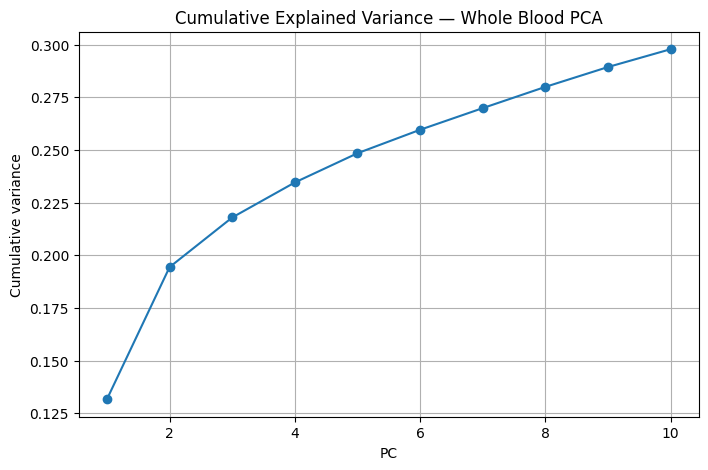

In [10]:
var = pca.explained_variance_ratio_
cum_var = np.cumsum(var)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.title("Cumulative Explained Variance — Whole Blood PCA")
plt.xlabel("PC"); plt.ylabel("Cumulative variance"); plt.grid(True)
plt.savefig(Config.FIGURES_DIR / "pca_whole_blood_cumulative_explained_variance.pdf",
            dpi=300, bbox_inches="tight")
plt.show()

## Save Processed Data

In [11]:
save_cache(X_wb, blood_subjid, blood_meta, df_meta_url, df_age)

Cache saved → /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/data/cache/processed_data.pkl  (372.8 MB)
